<a href="https://colab.research.google.com/github/alxmzr/Colab/blob/main/Breakout_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np

def backtest_breakout_probability(ticker_symbol, percentage_step=1.0, n_levels=5, period='1y'):
    # 1. Загрузка данных
    data = yf.download(ticker_symbol, period=period, interval='1d', auto_adjust=True)
    if data.empty:
        return "No data found"

    # Исправление MultiIndex заголовков, если они есть
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data.copy()

    # Подготовка колонок
    df['prev_open'] = df['Open'].shift(1)
    df['prev_close'] = df['Close'].shift(1)
    df['prev_high'] = df['High'].shift(1)
    df['prev_low'] = df['Low'].shift(1)

    df['is_green'] = df['prev_close'] > df['prev_open']
    df['is_red'] = df['prev_close'] < df['prev_open']

    g_total = 0
    r_total = 0
    hits = np.zeros((n_levels, 4))
    win = 0
    loss = 0

    # Итерируемся по строкам, пропуская первый пустой ряд
    for i in range(1, len(df)):
        row = df.iloc[i]
        if pd.isna(row['prev_open']):
            continue

        curr_h = row['High']
        curr_l = row['Low']
        step = row['prev_close'] * (percentage_step / 100)

        if row['is_green']: g_total += 1
        if row['is_red']: r_total += 1

        for lvl in range(n_levels):
            x = step * lvl
            hh_threshold = row['prev_high'] + x
            ll_threshold = row['prev_low'] - x

            if row['is_green']:
                if curr_h >= hh_threshold: hits[lvl, 0] += 1
                if curr_l <= ll_threshold: hits[lvl, 1] += 1
            elif row['is_red']:
                if curr_h >= hh_threshold: hits[lvl, 2] += 1
                if curr_l <= ll_threshold: hits[lvl, 3] += 1

        if g_total > 5 and r_total > 5:
            a1, b1 = hits[0,0]/g_total, hits[0,1]/g_total
            a2, b2 = hits[0,2]/r_total, hits[0,3]/r_total

            if row['is_green']:
                target_price = row['prev_high'] if a1 >= b1 else row['prev_low']
            else:
                target_price = row['prev_high'] if a2 >= b2 else row['prev_low']

            if target_price == row['prev_high']:
                if curr_h >= target_price: win += 1
                else: loss += 1
            else:
                if curr_l <= target_price: win += 1
                else: loss += 1

    wr = (win / (win + loss) * 100) if (win + loss) > 0 else 0
    return wr

# Запуск теста на SPY (3 роки)
wr_3y = backtest_breakout_probability('SPY', percentage_step=1.0, period='3y')
print(f"SPY 3Y Win Rate: {wr_3y:.2f}%")

[*********************100%***********************]  1 of 1 completed

SPY 3Y Win Rate: 67.89%


[*********************100%***********************]  1 of 1 completed

Запуск бектесту за останні 3 роки...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


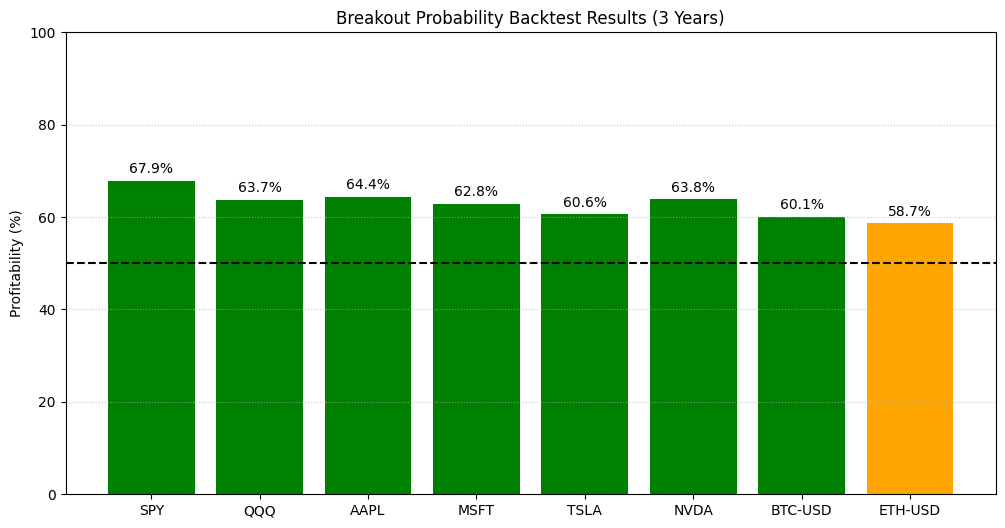

In [5]:
import matplotlib.pyplot as plt

tickers = ['SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA', 'BTC-USD', 'ETH-USD']
results_3y = {}

print("Запуск бектесту за останні 3 роки...")
for ticker in tickers:
    try:
        wr = backtest_breakout_probability(ticker, percentage_step=1.0, period='3y')
        results_3y[ticker] = wr
    except Exception as e:
        print(f"Помилка для {ticker}: {e}")

# Візуалізація
plt.figure(figsize=(12, 6))
ticker_names = list(results_3y.keys())
win_rates = list(results_3y.values())
colors = ['green' if x > 60 else 'orange' if x > 50 else 'red' for x in win_rates]

bars = plt.bar(ticker_names, win_rates, color=colors)
plt.axhline(y=50, color='black', linestyle='--')
plt.ylabel('Profitability (%)')
plt.title('Breakout Probability Backtest Results (3 Years)')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

Аналіз BTC-USD на різних таймфреймах...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

BTC 5m (period 60d): Win Rate 64.14%


BTC 15m (period 60d): Win Rate 64.85%


[*********************100%***********************]  1 of 1 completed


BTC 60m (period 730d): Win Rate 66.23%


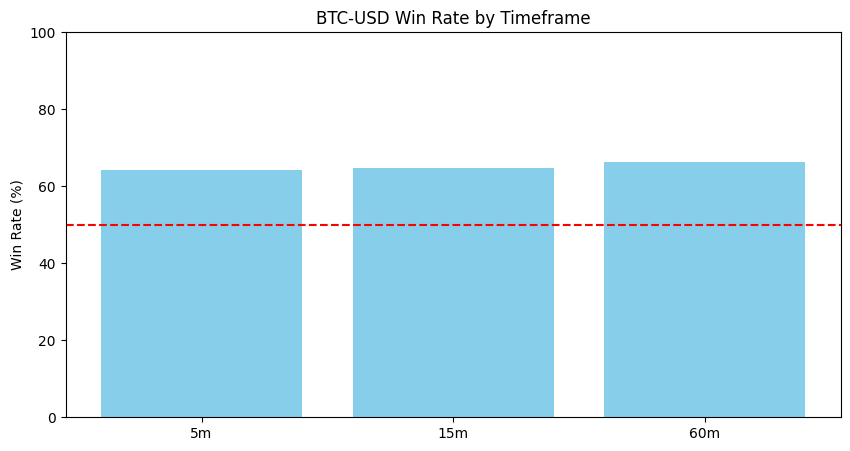

In [6]:
# Списки таймфреймів та відповідних періодів (обмеження yfinance)
timeframes = [
    {'interval': '5m', 'period': '60d'},
    {'interval': '15m', 'period': '60d'},
    {'interval': '60m', 'period': '730d'} # 60m = 1h
]

btc_results = {}

def backtest_intraday(ticker, interval, period):
    data = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    if data.empty: return 0
    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

    df = data.copy()
    df['prev_open'] = df['Open'].shift(1)
    df['prev_close'] = df['Close'].shift(1)
    df['prev_high'] = df['High'].shift(1)
    df['prev_low'] = df['Low'].shift(1)
    df['is_green'] = df['prev_close'] > df['prev_open']
    df['is_red'] = df['prev_close'] < df['prev_open']

    g_total, r_total, win, loss = 0, 0, 0, 0
    hits = np.zeros((1, 4)) # Беремо тільки 0-й рівень для швидкості

    for i in range(1, len(df)):
        row = df.iloc[i]
        if pd.isna(row['prev_open']): continue
        if row['is_green']: g_total += 1
        if row['is_red']: r_total += 1

        if row['is_green']:
            if row['High'] >= row['prev_high']: hits[0, 0] += 1
            if row['Low'] <= row['prev_low']: hits[0, 1] += 1
        elif row['is_red']:
            if row['High'] >= row['prev_high']: hits[0, 2] += 1
            if row['Low'] <= row['prev_low']: hits[0, 3] += 1

        if g_total > 10 and r_total > 10:
            a1, b1 = hits[0,0]/g_total, hits[0,1]/g_total
            a2, b2 = hits[0,2]/r_total, hits[0,3]/r_total
            target = row['prev_high'] if (a1 >= b1 if row['is_green'] else a2 >= b2) else row['prev_low']
            if (target == row['prev_high'] and row['High'] >= target) or (target == row['prev_low'] and row['Low'] <= target):
                win += 1
            else: loss += 1
    return (win / (win + loss) * 100) if (win + loss) > 0 else 0

print("Аналіз BTC-USD на різних таймфреймах...")
for tf in timeframes:
    wr = backtest_intraday('BTC-USD', tf['interval'], tf['period'])
    btc_results[tf['interval']] = wr
    print(f"BTC {tf['interval']} (period {tf['period']}): Win Rate {wr:.2f}%")

# Візуалізація результатів
plt.figure(figsize=(10, 5))
plt.bar(btc_results.keys(), btc_results.values(), color='skyblue')
plt.axhline(y=50, color='red', linestyle='--')
plt.title('BTC-USD Win Rate by Timeframe')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)
plt.show()

Аналіз ETH-USD на різних таймфреймах...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

ETH 5m (period 60d): Win Rate 64.50%


ETH 15m (period 60d): Win Rate 63.75%


[*********************100%***********************]  1 of 1 completed


ETH 60m (period 730d): Win Rate 63.87%


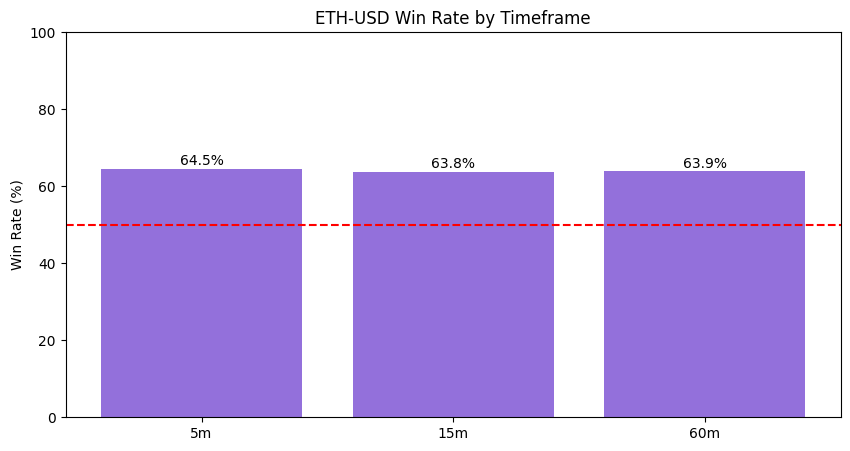

In [7]:
eth_results = {}

print("Аналіз ETH-USD на різних таймфреймах...")
for tf in timeframes:
    wr = backtest_intraday('ETH-USD', tf['interval'], tf['period'])
    eth_results[tf['interval']] = wr
    print(f"ETH {tf['interval']} (period {tf['period']}): Win Rate {wr:.2f}%")

# Візуалізація результатів
plt.figure(figsize=(10, 5))
plt.bar(eth_results.keys(), eth_results.values(), color='mediumpurple')
plt.axhline(y=50, color='red', linestyle='--')
plt.title('ETH-USD Win Rate by Timeframe')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 100)

for i, v in enumerate(eth_results.values()):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')

plt.show()

In [8]:
def calculate_expected_profit(win_rate, fee_percent=0.1):
    # Припускаємо середній рух ціни дорівнює percentage_step (1.0%)
    # При кожній угоді ми платимо комісію за вхід та вихід
    avg_gain = 1.0 # %
    total_fee = fee_percent * 2

    # Очікуваний прибуток: (Ймовірність виграшу * Чистий профіт) - (Ймовірність програшу * Збиток)
    # В даній моделі стоп-лосс та тейк-профіт симетричні навколо попереднього хая/лоу
    win_prob = win_rate / 100
    loss_prob = 1 - win_prob

    expected_val = (win_prob * avg_gain) - (loss_prob * avg_gain) - total_fee
    return expected_val

print("Очікуваний прибуток на угоду (при комісії 0.1%):")
for ticker, wr in results_3y.items():
    ev = calculate_expected_profit(wr)
    status = "✅" if ev > 0 else "❌"
    print(f"{ticker}: Win Rate {wr:.1f}%, Exp. Profit: {ev:.3f}% {status}")

Очікуваний прибуток на угоду (при комісії 0.1%):
SPY: Win Rate 67.9%, Exp. Profit: 0.158% ✅
QQQ: Win Rate 63.7%, Exp. Profit: 0.074% ✅
AAPL: Win Rate 64.4%, Exp. Profit: 0.087% ✅
MSFT: Win Rate 62.8%, Exp. Profit: 0.056% ✅
TSLA: Win Rate 60.6%, Exp. Profit: 0.012% ✅
NVDA: Win Rate 63.8%, Exp. Profit: 0.077% ✅
BTC-USD: Win Rate 60.1%, Exp. Profit: 0.001% ✅
ETH-USD: Win Rate 58.7%, Exp. Profit: -0.027% ❌


### Статистичний прогноз на наступний день
На основі розрахованої ймовірності пробою та останньої закритої свічки.

In [10]:
def get_next_day_forecast(ticker_symbol):
    data = yf.download(ticker_symbol, period='60d', interval='1d', auto_adjust=True)
    if data.empty: return "No data"
    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

    # Останні дані
    last_bar = data.iloc[-1]
    prev_close = last_bar['Close']
    prev_open = last_bar['Open']
    prev_high = last_bar['High']
    prev_low = last_bar['Low']
    is_green = prev_close > prev_open

    # Розраховуємо історичні ймовірності для цього активу за 1 рік
    # (Спрощений розрахунок hit rate для 0-го рівня)
    df = yf.download(ticker_symbol, period='1y', interval='1d', auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    df['p_open'] = df['Open'].shift(1)
    df['p_close'] = df['Close'].shift(1)
    df['p_high'] = df['High'].shift(1)
    df['p_low'] = df['Low'].shift(1)

    g_df = df[df['p_close'] > df['p_open']]
    r_df = df[df['p_close'] < df['p_open']]

    if is_green:
        prob_high = (g_df['High'] >= g_df['p_high']).mean() * 100
        prob_low = (g_df['Low'] <= g_df['p_low']).mean() * 100
    else:
        prob_high = (r_df['High'] >= r_df['p_high']).mean() * 100
        prob_low = (r_df['Low'] <= r_df['p_low']).mean() * 100

    direction = "UP (High)" if prob_high >= prob_low else "DOWN (Low)"
    target = prev_high if prob_high >= prob_low else prev_low
    conf = max(prob_high, prob_low)

    return {
        'Ticker': ticker_symbol,
        'Last Close': prev_close,
        'Direction': direction,
        'Target Price': target,
        'Probability': f"{conf:.1f}%"
    }

forecasts = []
for t in tickers:
    forecasts.append(get_next_day_forecast(t))

import pandas as pd
forecast_df = pd.DataFrame(forecasts)
display(forecast_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,Ticker,Last Close,Direction,Target Price,Probability
0,SPY,731.580017,DOWN (Low),729.750000,58.5%
1,QQQ,694.940002,DOWN (Low),691.770020,52.7%
2,AAPL,287.440002,DOWN (Low),285.779999,56.6%
3,MSFT,420.769989,UP (High),427.980011,65.6%
4,TSLA,411.790009,UP (High),415.829987,64.3%
5,NVDA,211.500000,UP (High),214.199997,69.2%
6,BTC-USD,79928.312500,DOWN (Low),79248.484375,62.3%
7,ETH-USD,2287.248047,DOWN (Low),2268.078857,59.6%


Порівняння точності прогнозів за горизонтами...


,Ticker,1Y,6M
0,SPY,67.916667,68.750000
1,QQQ,62.553191,64.285714
2,AAPL,63.445378,66.071429
3,MSFT,61.276596,62.727273
4,TSLA,60.851064,59.459459
5,NVDA,61.440678,59.459459
6,BTC-USD,62.994350,62.424242
7,ETH-USD,60.734463,57.575758


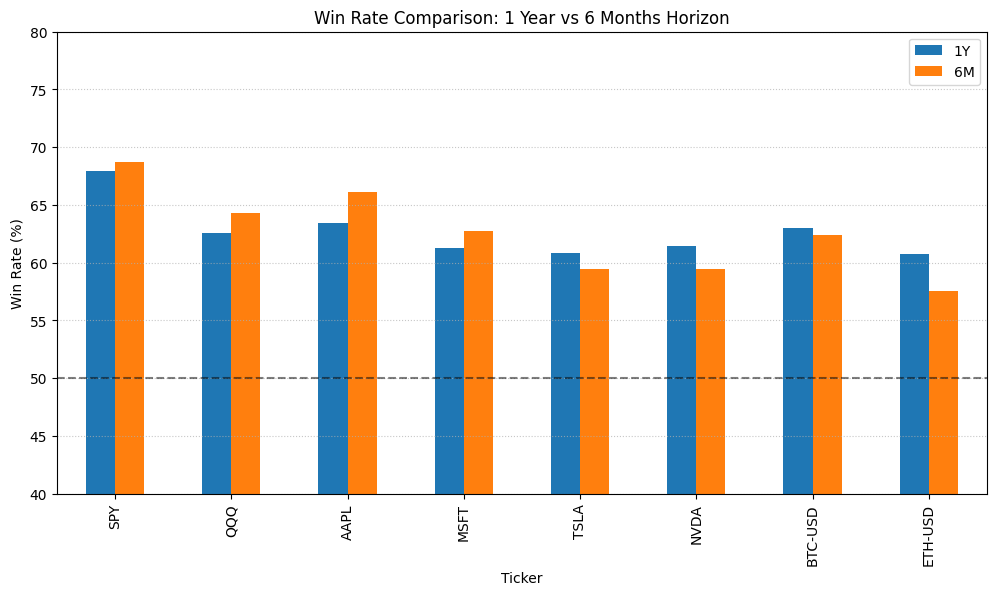

In [11]:
def compare_horizons(tickers, horizons={'1Y': '1y', '6M': '6mo'}):
    comparison_results = []

    for ticker in tickers:
        row = {'Ticker': ticker}
        for label, period in horizons.items():
            # Завантажуємо дані для конкретного горизонту
            df = yf.download(ticker, period=period, interval='1d', auto_adjust=True, progress=False)
            if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

            df['p_open'] = df['Open'].shift(1)
            df['p_close'] = df['Close'].shift(1)
            df['p_high'] = df['High'].shift(1)
            df['p_low'] = df['Low'].shift(1)

            win, total = 0, 0
            for i in range(1, len(df)):
                curr = df.iloc[i]
                if pd.isna(curr['p_open']): continue

                is_green = curr['p_close'] > curr['p_open']
                # Рахуємо історичний hit rate на цьому вікні до моменту i
                sub_df = df.iloc[:i]
                g_df = sub_df[sub_df['p_close'] > sub_df['p_open']]
                r_df = sub_df[sub_df['p_close'] < sub_df['p_open']]

                if len(g_df) < 5 or len(r_df) < 5: continue

                if is_green:
                    target = 'High' if (g_df['High'] >= g_df['p_high']).mean() >= (g_df['Low'] <= g_df['p_low']).mean() else 'Low'
                else:
                    target = 'High' if (r_df['High'] >= r_df['p_high']).mean() >= (r_df['Low'] <= r_df['p_low']).mean() else 'Low'

                if (target == 'High' and curr['High'] >= curr['p_high']) or (target == 'Low' and curr['Low'] <= curr['p_low']):
                    win += 1
                total += 1

            row[label] = (win / total * 100) if total > 0 else 0
        comparison_results.append(row)

    return pd.DataFrame(comparison_results)

print("Порівняння точності прогнозів за горизонтами...")
horizon_df = compare_horizons(tickers)
display(horizon_df)

# Візуалізація
horizon_df.set_index('Ticker').plot(kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Win Rate Comparison: 1 Year vs 6 Months Horizon')
plt.ylabel('Win Rate (%)')
plt.axhline(y=50, color='black', linestyle='--', alpha=0.5)
plt.ylim(40, 80)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

[*********************100%***********************]  1 of 1 completed

Запуск бектесту для макро-активів та Forex (3 роки)...



[*********************100%***********************]  1 of 1 completed

^GSPC: Win Rate 68.16%



[*********************100%***********************]  1 of 1 completed

...


[*********************100%***********************]  1 of 1 completed

AUDUSD=X: Win Rate 53.41%



[*********************100%***********************]  1 of 1 completed

NZDUSD=X: Win Rate 55.34%


USDJPY=X: Win Rate 61.39%


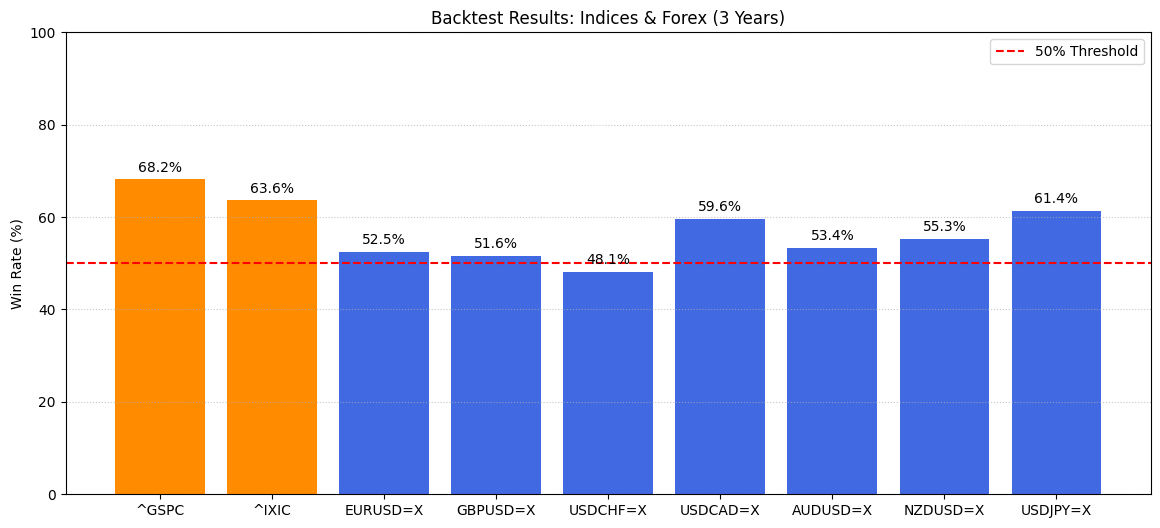

In [12]:
import matplotlib.pyplot as plt

# Новий список активів: Індекси та Форекс пари
# S&P500 (^GSPC), NASDAQ (^IXIC), та основні валютні пари
new_tickers = [
    '^GSPC', '^IXIC',
    'EURUSD=X', 'GBPUSD=X', 'USDCHF=X',
    'USDCAD=X', 'AUDUSD=X', 'NZDUSD=X', 'USDJPY=X'
]

results_macro = {}

print("Запуск бектесту для макро-активів та Forex (3 роки)...")
for ticker in new_tickers:
    try:
        # Використовуємо існуючу функцію backtest_breakout_probability
        wr = backtest_breakout_probability(ticker, percentage_step=0.5, period='3y')
        results_macro[ticker] = wr
        print(f"{ticker}: Win Rate {wr:.2f}%")
    except Exception as e:
        print(f"Помилка для {ticker}: {e}")

# Візуалізація
plt.figure(figsize=(14, 6))
names = list(results_macro.keys())
values = list(results_macro.values())
colors_macro = ['royalblue' if 'USD' in x else 'darkorange' for x in names]

bars = plt.bar(names, values, color=colors_macro)
plt.axhline(y=50, color='red', linestyle='--', label='50% Threshold')
plt.ylabel('Win Rate (%)')
plt.title('Backtest Results: Indices & Forex (3 Years)')
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')

plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

In [13]:
print("Розрахунок очікуваного прибутку для Forex (враховуючи менший спред/комісію 0.02%):")
for ticker, wr in results_macro.items():
    # Для форекс та індексів зазвичай комісії нижчі, ніж для акцій
    fee = 0.01 if '=' in ticker else 0.05
    ev = calculate_expected_profit(wr, fee_percent=fee)
    status = "✅" if ev > 0 else "❌"
    print(f"{ticker}: WR {wr:.1f}%, EV: {ev:.3f}% {status}")

Розрахунок очікуваного прибутку для Forex (враховуючи менший спред/комісію 0.02%):
^GSPC: WR 68.2%, EV: 0.263% ✅
^IXIC: WR 63.6%, EV: 0.173% ✅
EURUSD=X: WR 52.5%, EV: 0.031% ✅
GBPUSD=X: WR 51.6%, EV: 0.013% ✅
USDCHF=X: WR 48.1%, EV: -0.057% ❌
USDCAD=X: WR 59.6%, EV: 0.173% ✅
AUDUSD=X: WR 53.4%, EV: 0.048% ✅
NZDUSD=X: WR 55.3%, EV: 0.087% ✅
USDJPY=X: WR 61.4%, EV: 0.208% ✅


In [15]:
import plotly.graph_objects as go
from datetime import datetime, timedelta

def visualize_strategy(ticker_symbol, days=20):
    # Завантаження даних
    data = yf.download(ticker_symbol, period='60d', interval='1d', auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex): data.columns = data.columns.get_level_values(0)

    df = data.tail(days + 1).copy()
    df['p_high'] = df['High'].shift(1)
    df['p_low'] = df['Low'].shift(1)
    df['p_open'] = df['Open'].shift(1)
    df['p_close'] = df['Close'].shift(1)

    # Вибираємо останній період для відображення
    plot_df = df.iloc[1:].copy()

    fig = go.Figure(data=[go.Candlestick(x=plot_df.index,
                open=plot_df['Open'],
                high=plot_df['High'],
                low=plot_df['Low'],
                close=plot_df['Close'],
                name='Price')
    ])

    # Додаємо рівні попереднього дня
    fig.add_trace(go.Scatter(x=plot_df.index, y=plot_df['p_high'],
                             mode='markers', marker=dict(symbol='line-ew', size=10, color='green'),
                             name='Prev Day High'))

    fig.add_trace(go.Scatter(x=plot_df.index, y=plot_df['p_low'],
                             mode='markers', marker=dict(symbol='line-ew', size=10, color='red'),
                             name='Prev Day Low'))

    # Логіка сигналів для візуалізації
    for i, row in plot_df.iterrows():
        # Якщо пробито хай
        if row['High'] >= row['p_high']:
            fig.add_annotation(x=i, y=row['p_high'], text="Break High", showarrow=True, arrowhead=1, ax=0, ay=-20, bgcolor="green", font=dict(color="white"))
        # Якщо пробито лоу
        if row['Low'] <= row['p_low']:
            fig.add_annotation(x=i, y=row['p_low'], text="Break Low", showarrow=True, arrowhead=1, ax=0, ay=20, bgcolor="red", font=dict(color="white"))

    fig.update_layout(title=f'Strategy Visualization: {ticker_symbol} (Last {days} Days)',
                      yaxis_title='Price',
                      xaxis_title='Date',
                      xaxis_rangeslider_visible=False,
                      template='plotly_dark')
    fig.show()

visualize_strategy('SPY', days=15)

[*********************100%***********************]  1 of 1 completed
